# Fisher--Rao and Wasserstein Geodesics for One-Dimensional Gaussians

This notebook generates `fig:monge-gaussian-fr-mean-geodesic`.  The one-dimensional Gaussian family can be represented by the upper half-plane of mean and standard deviation coordinates $(m,\sigma)$.  Quadratic optimal transport gives the Euclidean geometry
$$
\mathcal W_2^2\bigl(\mathcal N(m_0,\sigma_0^2),\mathcal N(m_1,\sigma_1^2)\bigr)
=(m_0-m_1)^2+(\sigma_0-\sigma_1)^2,
$$
whereas the Fisher--Rao metric obtained from the local expansion of the Kullback--Leibler divergence is
$$
ds_{\mathrm{FR}}^2=\frac{dm^2+2\,d\sigma^2}{\sigma^2}.
$$
After the change of variable $x=m/\sqrt2$, $y=\sigma$, this is twice the usual hyperbolic metric on the upper half-plane.  The figure compares the straight Wasserstein geodesic with the curved Fisher--Rao geodesic and shows the corresponding Gaussian density interpolations.


In [1]:

from pathlib import Path
import sys
import shutil
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

ROOT = Path.cwd()
if not (ROOT / "notebooks-figures").exists():
    ROOT = ROOT.parent
sys.path.append(str(ROOT / "notebooks-figures"))

from figure_style import (
    RED, BLUE, VIOLET, GRAY, LIGHT_GRAY,
    DIRAC_MARKER_SIZE, setup_matplotlib, figure_dir, save_pdf,
    interp_color, box_axes,
)

setup_matplotlib()

NAME = "monge-gaussian-fr-mean-geodesic"
OUT = figure_dir(NAME)
THUMBNAIL = ROOT / "notebooks-figures" / "thumbnails" / f"{NAME}.png"
ARXIV_OUT = ROOT / "arxiv" / "figures"
ARXIV_OUT.mkdir(parents=True, exist_ok=True)


def gaussian_pdf(x, m, sigma):
    return np.exp(-0.5 * ((x - m) / sigma) ** 2) / (np.sqrt(2 * np.pi) * sigma)


def fisher_rao_distance(m0, s0, m1, s1):
    arg = 1.0 + ((m0 - m1) ** 2 + 2.0 * (s0 - s1) ** 2) / (4.0 * s0 * s1)
    return np.sqrt(2.0) * np.arccosh(arg)


def w2_path(m0, s0, m1, s1, ts):
    return np.column_stack(((1 - ts) * m0 + ts * m1, (1 - ts) * s0 + ts * s1))


def fisher_rao_path(m0, s0, m1, s1, ts):
    "Constant-speed Fisher--Rao geodesic in (m,sigma) coordinates."
    x0, y0 = m0 / np.sqrt(2.0), s0
    x1, y1 = m1 / np.sqrt(2.0), s1
    if abs(x1 - x0) < 1e-14:
        y = np.exp((1 - ts) * np.log(y0) + ts * np.log(y1))
        x = np.full_like(y, x0)
    else:
        center = (x1 * x1 + y1 * y1 - x0 * x0 - y0 * y0) / (2.0 * (x1 - x0))
        radius = np.sqrt((x0 - center) ** 2 + y0 ** 2)
        theta0 = np.arctan2(y0, x0 - center)
        theta1 = np.arctan2(y1, x1 - center)
        q0 = np.log(np.tan(theta0 / 2.0))
        q1 = np.log(np.tan(theta1 / 2.0))
        theta = 2.0 * np.arctan(np.exp((1 - ts) * q0 + ts * q1))
        x = center + radius * np.cos(theta)
        y = radius * np.sin(theta)
    return np.column_stack((np.sqrt(2.0) * x, y))


def colored_path(ax, path, *, lw=1.75, linestyle="-", alpha=1.0, zorder=3):
    segments = np.stack([path[:-1], path[1:]], axis=1)
    colors = [(*interp_color(k / max(len(segments) - 1, 1)), alpha) for k in range(len(segments))]
    lc = LineCollection(segments, colors=colors, linewidths=lw, linestyles=linestyle, zorder=zorder)
    ax.add_collection(lc)


m0, s0 = -1.35, 0.36
m1, s1 = 1.35, 0.86
ts_line = np.linspace(0.0, 1.0, 241)
ts_marks = np.linspace(0.0, 1.0, 7)
w2 = w2_path(m0, s0, m1, s1, ts_line)
fr = fisher_rao_path(m0, s0, m1, s1, ts_line)
w2_marks = w2_path(m0, s0, m1, s1, ts_marks)
fr_marks = fisher_rao_path(m0, s0, m1, s1, ts_marks)
print("Fisher--Rao distance:", fisher_rao_distance(m0, s0, m1, s1))


Fisher--Rao distance: 3.7829716053865394


## Upper-half-plane geodesics

The Wasserstein geodesic is the Euclidean segment in $(m,\sigma)$, drawn with neutral gray samples.  The Fisher--Rao geodesic is a hyperbolic geodesic after the rescaling $m\mapsto m/\sqrt2$, hence it appears as a colored curved arc in the displayed $(m,\sigma)$ coordinates.


In [2]:

fig, ax = plt.subplots(figsize=(2.65, 2.08))
ax.plot(w2[:, 0], w2[:, 1], color="#81786d", lw=1.05, linestyle=(0, (1.5, 1.8)), alpha=0.70, zorder=1)
colored_path(ax, fr, lw=1.95, zorder=3)
for t, p in zip(ts_marks, w2_marks):
    ax.scatter([p[0]], [p[1]], s=DIRAC_MARKER_SIZE * (0.62 if t not in [0.0, 1.0] else 0.78),
               facecolor="white", edgecolor="#81786d", linewidth=0.55, zorder=4)
for t, p in zip(ts_marks, fr_marks):
    ax.scatter([p[0]], [p[1]], s=DIRAC_MARKER_SIZE * (0.68 if t not in [0.0, 1.0] else 1.00),
               color=interp_color(float(t)), edgecolor="none", linewidth=0, zorder=5)
ax.set_xlim(-1.65, 1.65)
ax.set_ylim(0.20, 1.24)
ax.set_xlabel(r"mean $m$")
ax.set_ylabel(r"std. dev. $\sigma$")
box_axes(ax)
save_pdf(fig, OUT / "halfplane.pdf", pad_inches=0.050)
plt.close(fig)
shutil.copy2(OUT / "halfplane.pdf", ARXIV_OUT / f"{NAME}--halfplane.pdf")


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


PosixPath('/Users/gpeyre/Dropbox/github/ot4ml/arxiv/figures/monge-gaussian-fr-mean-geodesic--halfplane.pdf')

## Density interpolations

Both interpolations remain inside the Gaussian family.  The left density panel follows the Wasserstein straight segment in $(m,\sigma)$; the right density panel follows the Fisher--Rao hyperbolic geodesic.


In [3]:

def draw_density_panel(path, filename):
    x = np.linspace(-3.35, 3.45, 760)
    fig, ax = plt.subplots(figsize=(2.65, 2.08))
    curves = []
    max_rho = 0.0
    for t, (m, s) in zip(ts_marks, path):
        rho = gaussian_pdf(x, m, s)
        curves.append((float(t), rho))
        max_rho = max(max_rho, float(rho.max()))
    for t, rho in curves:
        ax.plot(x, rho, color=interp_color(t), lw=1.55 if t in [0.0, 1.0] else 1.05, alpha=0.95)
    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(0.0, 1.08 * max_rho)
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"density")
    box_axes(ax)
    save_pdf(fig, OUT / filename, pad_inches=0.050)
    plt.close(fig)
    shutil.copy2(OUT / filename, ARXIV_OUT / f"{NAME}--{filename}")


draw_density_panel(w2_marks, "densities-w2.pdf")
draw_density_panel(fr_marks, "densities-fr.pdf")


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


## Notebook preview

The preview below is the thumbnail used by the searchable figure gallery.


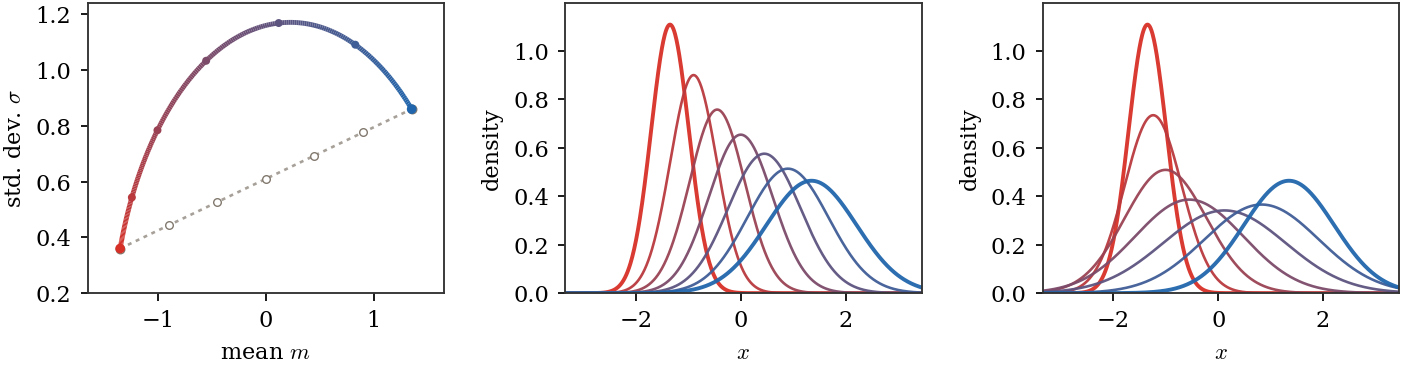

In [4]:

from IPython.display import Image, display

fig, axes = plt.subplots(1, 3, figsize=(7.75, 2.12))
ax = axes[0]
ax.plot(w2[:, 0], w2[:, 1], color="#81786d", lw=1.05, linestyle=(0, (1.5, 1.8)), alpha=0.70, zorder=1)
colored_path(ax, fr, lw=1.95, zorder=3)
for t, p in zip(ts_marks, w2_marks):
    ax.scatter([p[0]], [p[1]], s=DIRAC_MARKER_SIZE * (0.62 if t not in [0.0, 1.0] else 0.78), facecolor="white", edgecolor="#81786d", linewidth=0.55, zorder=4)
for t, p in zip(ts_marks, fr_marks):
    ax.scatter([p[0]], [p[1]], s=DIRAC_MARKER_SIZE * (0.68 if t not in [0.0, 1.0] else 1.00), color=interp_color(float(t)), edgecolor="none", linewidth=0, zorder=5)
ax.set_xlim(-1.65, 1.65)
ax.set_ylim(0.20, 1.24)
ax.set_xlabel(r"mean $m$")
ax.set_ylabel(r"std. dev. $\sigma$")
box_axes(ax)

x = np.linspace(-3.35, 3.45, 760)
for ax, path in zip(axes[1:], [w2_marks, fr_marks]):
    max_rho = 0.0
    curves = []
    for t, (m, s) in zip(ts_marks, path):
        rho = gaussian_pdf(x, m, s)
        curves.append((float(t), rho))
        max_rho = max(max_rho, float(rho.max()))
    for t, rho in curves:
        ax.plot(x, rho, color=interp_color(t), lw=1.55 if t in [0.0, 1.0] else 1.05, alpha=0.95)
    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(0.0, 1.08 * max_rho)
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"density")
    box_axes(ax)
fig.subplots_adjust(left=0.055, right=0.995, bottom=0.22, top=0.98, wspace=0.34)
THUMBNAIL.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(THUMBNAIL, dpi=180, bbox_inches="tight", pad_inches=0.02)
plt.close(fig)
display(Image(filename=str(THUMBNAIL)))
